# Visualization of Feature Maps 

Reference: https://www.geeksforgeeks.org/deep-learning/visualizing-feature-maps-using-pytorch/

Feature Maps are the output of particular kernel applied to the original input. Each feature map extracts the specific feature and visualizing them helps to develop intuition about CNN's inner working process and debugging.

In [12]:
# Necessary imports
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Load, Display and Pre-process one input image

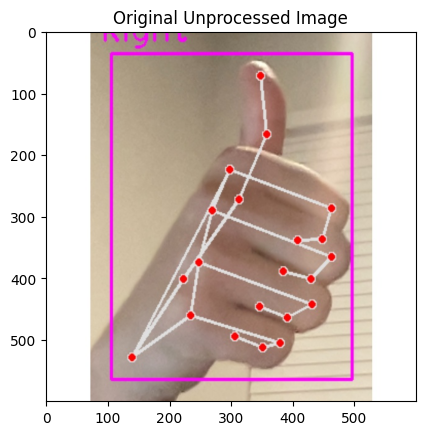

In [ ]:
# Load the input image and display
IMG_SIZE = 128
imgPath = '../../data/0/Image_1769660859.528964.jpg'

inputImageOriginal = image.load_img(imgPath)
plt.imshow(inputImageOriginal)
plt.title("Original Unprocessed Image")
plt.show()


Pre-process the image to match the input format for the model

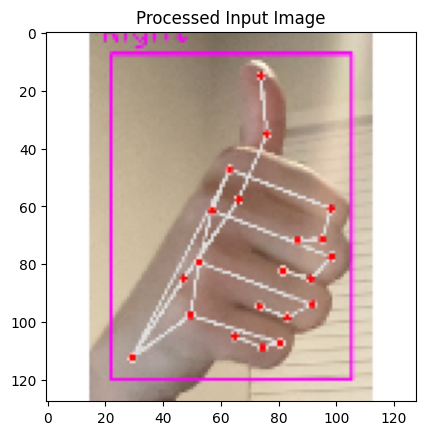

In [ ]:
inputImage = image.load_img(imgPath, target_size=(IMG_SIZE, IMG_SIZE))
inputImage = image.img_to_array(inputImage)
inputImage = inputImage / 255.0

plt.imshow(inputImage)
plt.title("Processed Input Image")
plt.show()

inputImage = np.expand_dims(inputImage, axis=0) # increase the dimension after displaying the image

Next step is to load the model and extract the Conv2D layers

In [19]:
model = tf.keras.models.load_model("../models/hand_gesture_cnn_old.h5")

convLayers = []

for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        convLayers.append(layer)

print("Conv Layers: ")

for layer in convLayers:
    print(layer.name, layer.output.shape)


Conv Layers: 
conv2d (None, 126, 126, 32)
conv2d_1 (None, 61, 61, 64)
conv2d_2 (None, 28, 28, 128)


Build a feature-map extractor model

In [20]:
featureExtractor = Model(
    inputs = model.input,
    outputs = [layer.output for layer in convLayers]
)

# This creates a new Keras model that takes the same input image as the orginal CNN, but instead outputs the activation (feature maps)

In [21]:
featureMaps = featureExtractor.predict(inputImage)

1/1 [==============================] - 0s 151ms/step


Mean Feature Map -> one image per Conv Layer

In [22]:
proccessedFeatureMaps = []

for fmap in featureMaps:
    fmap = fmap[0] # remove the batch dim
    mean_fmap = np.mean(fmap, axis=-1) # mean over channels
    proccessedFeatureMaps.append(mean_fmap)

Plot the extracted feature maps

<function matplotlib.pyplot.show(close=None, block=None)>

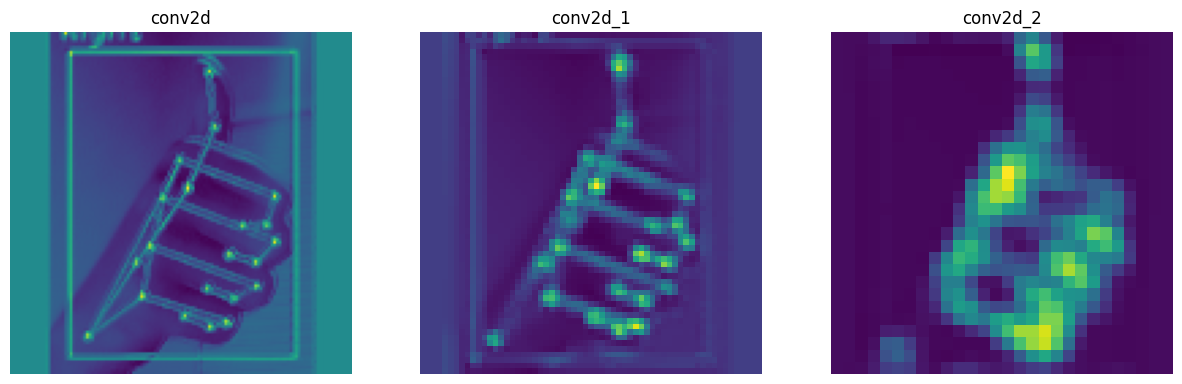

In [ ]:
plt.figure(figsize=(15,10))

for i, fmap in enumerate(proccessedFeatureMaps):
    plt.subplot(1, len(proccessedFeatureMaps), i+1)
    plt.imshow(fmap, cmap="viridis") # cmap means colorMap, and viridis is for activation visualization
    plt.title(convLayers[i].name)
    plt.axis("off")

plt.show

## Visualizing Individual Filters

Early Layers extract edges, corners
Middle Layers extract textures
Deeper Layers extract shapes/parts of hands

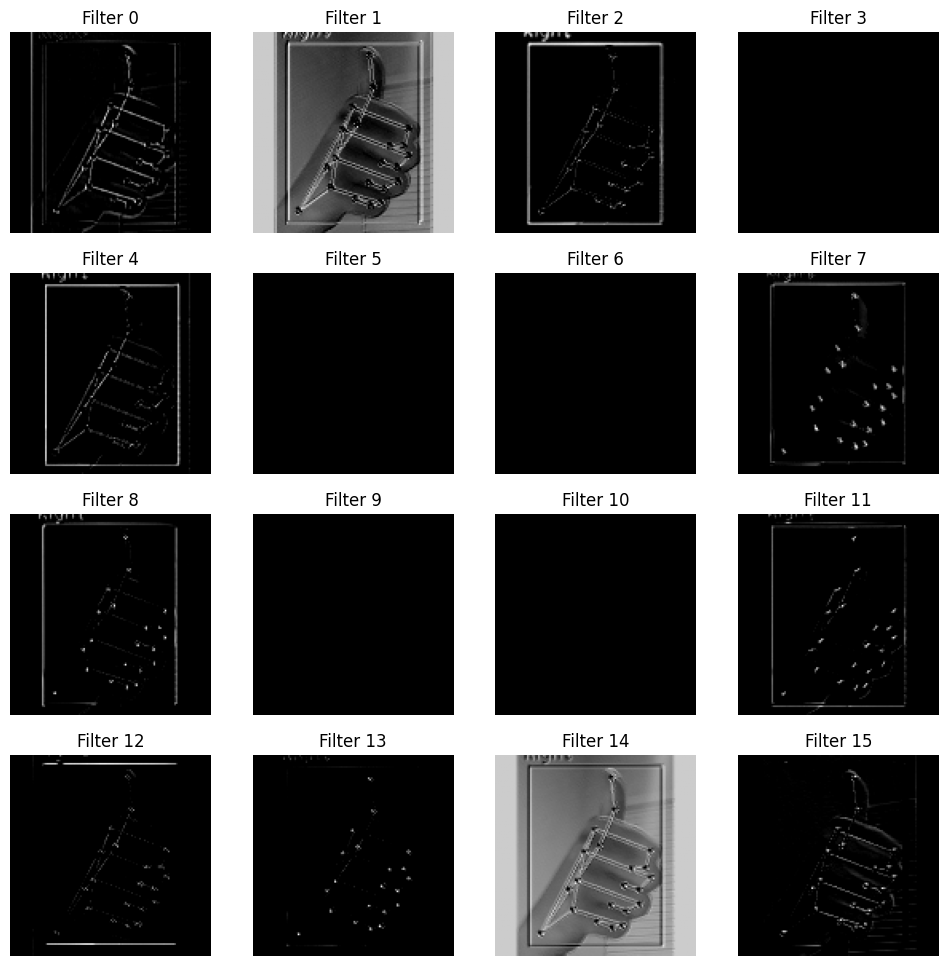

In [27]:
# First Conv Layer (32 filters)

fmap = featureMaps[0][0] # remove batch dim

plt.figure(figsize=(12, 12))

for i in range(min(16, fmap.shape[-1])): # show upto 16 feature maps
    plt.subplot(4, 4, i+ 1) # creates a 4 x 4 grid of plots starting at i 
    plt.imshow(fmap[:, :, i], cmap="gray") # fmap[:, :, i] -> selects all rows, all columns and only filter i
    plt.title(f"Filter {i}")
    plt.axis("off")


plt.show()